# Logistic Regression + Reduced Dataset using PCA

In this  notebook, we are training a model using PCA to reduce our features.

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

import matplotlib.pyplot as plt

In [ ]:
path = ['../Data/X_train.csv', '../Data/y_train.csv']
X_train, y_train = [pd.read_csv(f, index_col=0) for f in path]
y_train=np.array(y_train['Cluster'])

## Visualizing PCA Components

We create a Scree plot to visualize how the explained variance changed with each component to decide on the best option.

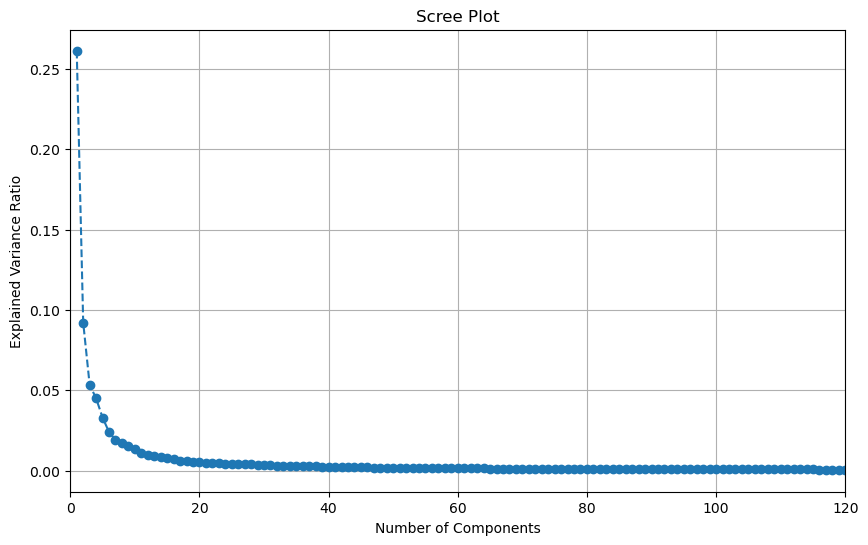

In [3]:
pca_all = PCA()
pca_all.fit(StandardScaler().fit_transform(X_train))
explained_variance_ratio = pca_all.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.xlim((0,120))
plt.grid(True)
plt.show()

In [6]:
# Checking choosing the amount of variance affects the number of components we get
pca = PCA(n_components=0.675)  
X_train_pca = pca.fit_transform(X_train)
print(f"Number of components chosen: {pca.n_components_}")


Number of components chosen: 20


## Hyperparameter tuning

We now run NestedCV to find the best parameter for our model.

In [5]:
# Define pipeline
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('model', LogisticRegression(max_iter=10000))
])


# Define parameter grid for tuning
param_grid = {
    'pca__n_components': [5, 10, 20, 40],
    'model__C': [0.001, 0.01, 0.1, 1, 10], 
    'model__penalty': ['l1', 'l2'],              # can test 'l1' if using solver='liblinear'
    'model__solver': ['liblinear', 'saga'],
    'model__max_iter': [20000]
}


# 2) Nested CV
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
nested_scores_auc = []
nested_scores_acc = []

inner_cv_scores = []
best_params_list = []


X = X_train.copy()
y= y_train.copy()

i=1
for train_idx, test_idx in outer_cv.split(X, y):
    X_outer_train, X_outer_test = X.iloc[train_idx], X.iloc[test_idx]
    y_outer_train, y_outer_test = y[train_idx], y[test_idx]
    
    # Inner CV for hyperparameter tuning
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    grid_search = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    inner_cv_scores.append(float(grid_search.best_score_))
    best_params_list.append(grid_search.best_params_)

    
    # Evaluate best model on outer test fold
    best_inner_model = clone(grid_search.best_estimator_)
    best_inner_model.fit(X_outer_train, y_outer_train)

    y_outer_proba = best_inner_model.predict_proba(X_outer_test)[:, 1]
    auc = roc_auc_score(y_outer_test, y_outer_proba)
    nested_scores_auc.append(auc)

    acc = accuracy_score(y_outer_test, best_inner_model.predict(X_outer_test))
    nested_scores_acc.append(acc)

    print(f'Fold {i} complete')
    i=i+1

print("\nNested CV (unbiased estimate):")
print("Inner fold accuracies:", inner_cv_scores)
print("Outer fold accuracies:", nested_scores_acc)
print(f"Mean Accuracy: {np.mean(nested_scores_acc)} ± {np.std(nested_scores_acc)}")

print("Outer fold ROC-AUC:", nested_scores_auc)
print(f"Mean ROC-AUC: {np.mean(nested_scores_auc)} ± {np.std(nested_scores_auc)}")

# Summarize best parameters across folds
best_params_df = pd.DataFrame(best_params_list)
print("\nBest parameters per outer fold:")
print(best_params_df)

# Choose the most frequent or best-performing parameter set
final_best_params = best_params_df.mode().iloc[0].to_dict()
print("\nFinal chosen parameters for full training:")
print(final_best_params)


Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete

Nested CV (unbiased estimate):
Inner fold accuracies: [0.9016227180527384, 0.8999887311246338, 0.8999887311246338, 0.8999887311246338, 0.8999887311246338]
Outer fold accuracies: [0.9098360655737705, 0.8688524590163934, 0.9098360655737705, 0.9098360655737705, 0.8524590163934426]
Mean Accuracy: 0.8901639344262297 ± 0.02464474816126709
Outer fold ROC-AUC: [0.9392446633825944, 0.9346469622331691, 0.958656330749354, 0.9441214470284238, 0.9521963824289406]
Mean ROC-AUC: 0.9457731571644965 ± 0.00867612327597063

Best parameters per outer fold:
   model__C  model__max_iter model__penalty model__solver  pca__n_components
0       0.1            20000             l2     liblinear                 10
1       0.1            20000             l2     liblinear                 10
2       0.1            20000             l2     liblinear                 10
3       0.1            20000             l2     liblinear           